In [2]:
import pandas            as pd
import matplotlib.pyplot as plt
import numpy             as np

import matplotlib
import sys


sys.path.append('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk')

# Import Diego's tools
from WCSimFilePackages.npz_to_df     import simple_truehits_info_to_df, digihits_info_to_df, super_simple_track_info_to_df, simple_track_info_to_df, truehits_info_to_df
from WCTE_event_display.EventDisplay import EventDisplay

from tqdm.notebook import tqdm

import hipy.hipy.pltext as pltext

%load_ext autoreload
%autoreload 2

pd.set_option('display.max_rows', 100000)
pd.set_option('display.max_columns', 100000)
pltext.style()

In [3]:
npz = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/1Mneutrons_9cmNiCf_piFix_QGSP_BIC_HP_pos000_CDSON_10kevents.npz'
nevents  = 10000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_9cm = truehits_info_to_df(npz).dropna()
# df_digiHits_down = digihits_info_to_df(npz, nevents).dropna()
df_simpleTracks_9cm  = simple_track_info_to_df(npz).dropna()

# df_simpleTracks["world_i"] = np.where(df_simpleTracks["track_ri"] < 6.75, "nicf", "water")
# df_simpleTracks["world_f"] = np.where(df_simpleTracks["track_rf"] < 6.75, "nicf", "water")

In [4]:
# npz = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos000_CDSON_10kevents.npz'
npz = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/HK_9cmNiCf_000.npz'

nevents  = 10000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_6cm = truehits_info_to_df(npz).dropna()
# df_digiHits_down = digihits_info_to_df(npz, nevents).dropna()
df_simpleTracks_6cm  = simple_track_info_to_df(npz).dropna()

In [9]:
df_simpleTracks[df_simpleTracks["event_id"].values == 0]

,event_id,track_pid,track_id,track_parent,track_creator_process,track_energy,track_ti,track_ri,track_rf,world_i,world_f
0,0,0,0,0,initial,0.0,0.0,0.0,0.0,nicf,nicf
0,0,0,0,0,initial,0.0,0.0,0.0,0.0,nicf,nicf
0,0,2112,1,0,initial,942.646423,0.0,0.0,28.469797,nicf,water
0,0,2112,2,0,initial,941.124146,0.0,0.0,4.894313,nicf,nicf
0,0,2112,3,0,initial,943.93042,0.0,0.0,15.601968,nicf,water
...,...,...,...,...,...,...,...,...,...,...,...
0,0,11,355,337,phot,0.511058,83672.289062,12.923843,12.923843,water,water
0,0,11,356,337,phot,0.511773,83672.289062,12.923843,12.923843,water,water
0,0,11,357,337,phot,0.51105,83672.289062,12.923843,12.923843,water,water
0,0,11,358,337,phot,0.511048,83672.289062,12.923843,12.923843,water,water


In [3]:
df_simpleTracks[(df_simpleTracks["track_pid"].values == 22) & (df_simpleTracks["track_creator_process"].values == "nCapture") & (df_simpleTracks["world_i"].values == "nicf")]

,event_id,track_pid,track_id,track_parent,track_creator_process,track_energy,track_ti,track_ri,track_rf,world_i,world_f
0,0,22,29,4,nCapture,5.145336,76868.320312,5.428988,6.098395,nicf,nicf
0,0,22,30,4,nCapture,3.853912,76868.320312,5.428988,74.536613,nicf,water
1,1,22,10,1,nCapture,2.223056,37334.40625,6.394859,57.45467,nicf,water
1,1,22,16,3,nCapture,2.223056,109973.804688,4.673027,92.785629,nicf,water
4,4,22,6,1,nCapture,2.223055,174139.625,6.259736,52.158329,nicf,water
...,...,...,...,...,...,...,...,...,...,...,...
9997,9997,22,7,1,nCapture,5.873553,17189.607422,1.817925,23.771912,nicf,water
9997,9997,22,8,1,nCapture,2.786122,17189.607422,1.817925,52.328884,nicf,water
9997,9997,22,9,1,nCapture,0.339447,17189.707031,1.817925,38.46307,nicf,water
9998,9998,22,26,4,nCapture,2.223056,125089.117188,5.128808,23.595863,nicf,water


In [4]:
noHits_2hnicf = []
for i in range(1000):
    temp_df = df_simpleTracks[df_simpleTracks["event_id"].values == i]
    gammas  = temp_df[(temp_df["track_pid"].values == 22) & (temp_df["track_creator_process"].values == "nCapture") & (temp_df["world_i"].values == "nicf")]["track_id"].values
    electrons = temp_df[(temp_df["track_parent"].isin(gammas))]["track_id"].values
    noHits_2hnicf.append(len(df_trueHits_down[(df_trueHits_down["event_id"].values == i) & (df_trueHits_down["true_hit_parent"].isin(electrons))]))

noHits_2hwater = []
for i in range(1000):
    temp_df = df_simpleTracks[df_simpleTracks["event_id"].values == i]
    gammas  = temp_df[(temp_df["track_pid"].values == 22) & (temp_df["track_creator_process"].values == "nCapture") & (temp_df["world_i"].values == "water")]["track_id"].values
    electrons = temp_df[(temp_df["track_parent"].isin(gammas))]["track_id"].values
    noHits_2hwater.append(len(df_trueHits_down[(df_trueHits_down["event_id"].values == i) & (df_trueHits_down["true_hit_parent"].isin(electrons))]))

noHits_gamma = []
for i in range(1000):
    temp_df = df_simpleTracks[df_simpleTracks["event_id"].values == i]
    gammas  = temp_df[(temp_df["track_pid"].values == 22)]["track_id"].values
    electrons = temp_df[(temp_df["track_parent"].isin(gammas))]["track_id"].values
    noHits_gamma.append(len(df_trueHits_down[(df_trueHits_down["event_id"].values == i) & (df_trueHits_down["true_hit_parent"].isin(electrons))]))

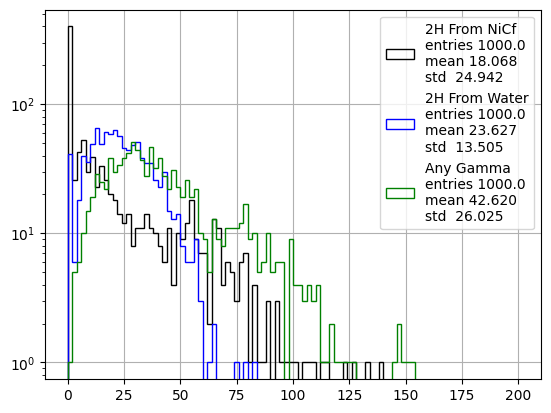

In [5]:
pltext.hist(noHits_2hnicf,  100, range=(0,200), ylog=True, label="2H From NiCf");
pltext.hist(noHits_2hwater, 100, range=(0,200), ylog=True, label="2H From Water");
pltext.hist(noHits_gamma,   100, range=(0,200), ylog=True, label="Any Gamma");

In [6]:
noHits_nio = []
for i in range(1000):
    temp_df    = df_simpleTracks[df_simpleTracks["event_id"].values == i]
    nio_parent = temp_df[(temp_df["track_pid"].values == 1000280590)]["track_parent"].values
    gammas     = temp_df[(temp_df["track_pid"].values == 22) & (temp_df["track_parent"].isin(nio_parent))]["track_id"].values
    electrons  = temp_df[(temp_df["track_parent"].isin(gammas))]["track_id"].values
    noHits_nio.append(len(df_trueHits_down[(df_trueHits_down["event_id"].values == i) & (df_trueHits_down["true_hit_parent"].isin(electrons))]))

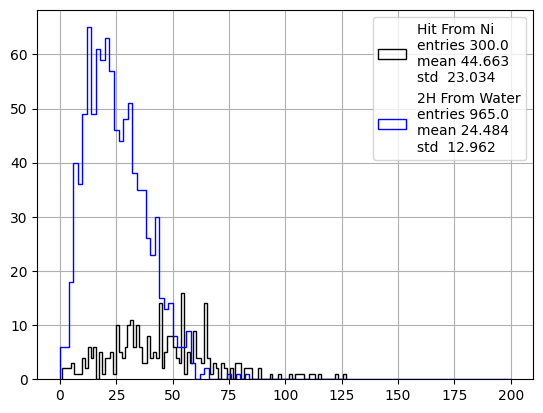

In [7]:
pltext.hist([i for i in noHits_nio if i!=0],     100,                ylog=False, label="Hit From Ni");
pltext.hist([i for i in noHits_2hwater if i!=0], 100, range=(0,200), ylog=False, label="2H From Water");

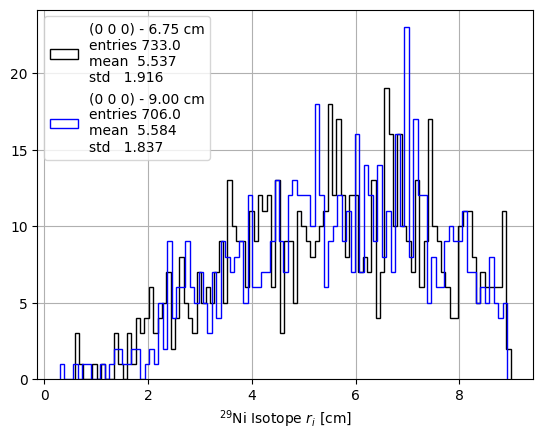

In [6]:
pltext.hist(df_simpleTracks_6cm[df_simpleTracks_6cm["track_pid"].values == 1000280590]["track_ri"], 100, xylabels="$^{29}$Ni Isotope $r_i$ [cm]", label="(0 0 0) - 6.75 cm");
pltext.hist(df_simpleTracks_9cm[df_simpleTracks_9cm["track_pid"].values == 1000280590]["track_ri"], 100, xylabels="$^{29}$Ni Isotope $r_i$ [cm]", label="(0 0 0) - 9.00 cm");